PROGETTO SISTEMI COMPLESSI!!!

importazioni pacchetti e librerie

In [4]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# libreria per grafici 3D
import plotly.graph_objects as go

#libreria utile per coefficienti di lyapunov
from jitcode import jitcode_lyap, y, t

Implementazioni del sistema di ODE del paper

parametri e funzioni del primo sistema
è importante rispettare certi vincoli sennò il sistema non ha soluzioni ben definite e gli algoritmi si incastrano...

In [5]:
# carrying capacity di X
k0 = 3
k1 = 4

#parametri del sistema adimensionalizzato
a1 = 4
a2 = 0.2
a3 = 0.8
a4 = 3
a5 = 2
a6 = 0.15
a7 = 0.8
a8 = 0.5
a9 = 1.5
a10 = 0.2


### Modello di Beddington-Angelis
Il sistema di equazioni differenziali è definito come segue:

$$
\begin{cases}
\displaystyle \frac{dx}{dt} = \frac{r_0(k_0 - x)x}{k_1 - x} - \frac{a_1 xy}{a_2 y + a_3 x + 1} = x f(x, y, z) \\
\displaystyle \frac{dy}{dt} = \frac{a_4 xy}{a_2 y + a_3 x + 1} - \frac{a_5 yz}{a_6 z + a_7 y + a_8} - y = y g(x, y, z) \\
\displaystyle \frac{dy}{dt} = \frac{a_9 yz}{a_6 z + a_7 y + a_8} - a_{10} z = z h(x, y, z)
\end{cases}
$$

In [6]:
def beddingtonAngelis(t, y, r, k0):
    X, Y, Z = y

    dX_dt = (r * (k0 - X) * X) / (k1 - X) - (a1 * X * Y) / (a2 * Y + a3 * X + 1) 
    dY_dt = (a4 * X * Y) / (a2 * Y + a3 * X + 1) - (a5 * Y * Z) / (a6 * Z + a7 * Y + a8) - Y 
    dZ_dt = (a9 * Y * Z) / (a6 * Z + a7 * Y + a8) - (a10 * Z)

    return [dX_dt, dY_dt, dZ_dt]

condizioni iniziali e simulazione,
variazione di r0: 

2 < r0 < 9

In [7]:
X0 = 0.1
Y0 = 0.1
Z0 = 0.1

y0 = [X0, Y0, Z0]

# simuliamo per 100 unità, analizzando le ultime 400
#t_span = (0,1000)
#t_eval = np.linspace(600, 1000, 1000)

t_span = (0,2000)
t_eval = np.linspace(1600, 2000, 2000)

In [8]:
r_plotz = []
r_ploty = []
z_plot = []
y_plot = []

print("Simulazione in corso...")
r_values = np.linspace(2,9,300)

for r in r_values:
    # Condizioni iniziali fisse come da paper
    y_init = [0.1, 0.1, 0.1]
    
    # Usiamo RK45
    sol = solve_ivp(
        beddingtonAngelis, t_span, y_init, args=(r, k0,), 
        t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-8)
    
    z_values = sol.y[2]
    y_values = sol.y[1]
    # find_peaks trova i massimi locali per il diagramma
    peaksz, _ = find_peaks(z_values)

    # aggiungiamo dista
    peaksy, _ = find_peaks(y_values, prominence=5e-3)
        
    if len(peaksz) > 0 and len(peaksy) > 0:
        # Prendiamo i picchi unici per evitare sovrapposizioni inutili
        for p in peaksz[-30:]: 
            r_plotz.append(r)
            z_plot.append(z_values[p])
        for p in peaksy[-30:]:
            r_ploty.append(r)
            y_plot.append(y_values[p])
            

Simulazione in corso...


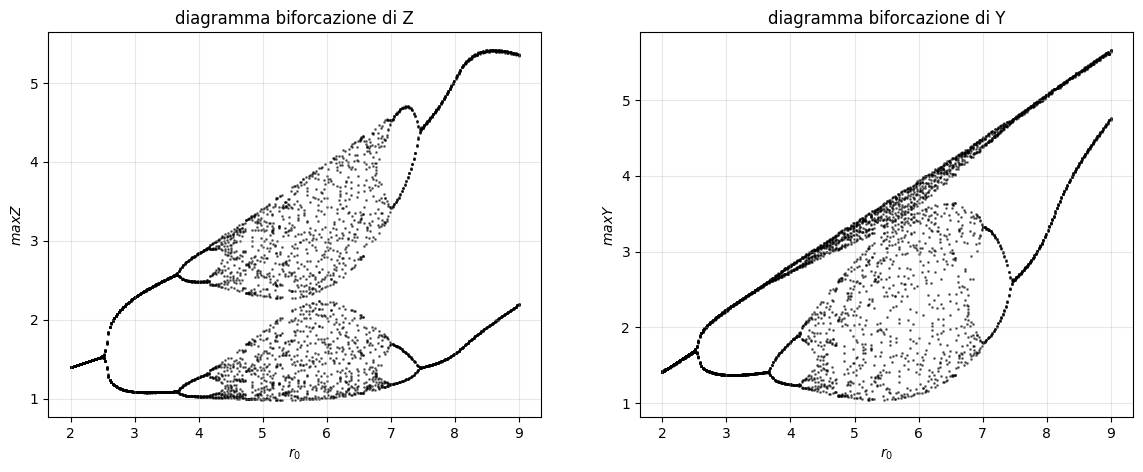

In [9]:
# Grafico biforcazione di Z
def plotresults(r_ploty, r_plotz, y_plot, z_plot):
    fig, (ax1, ax2) = plt.subplots(1,2, figsize = (14,5))

    ax1.scatter(r_plotz, z_plot, s = 1, c = "black", alpha = 0.5)
    ax1.set_title("diagramma biforcazione di Z")
    ax1.set_xlabel('$r_0$')
    ax1.set_ylabel('$maxZ$')
    ax1.grid(alpha=0.3)

    # Grafico biforcazione di Y
    ax2.scatter(r_ploty, y_plot, s = 1, c = "black", alpha = 0.5)
    ax2.set_title("diagramma biforcazione di Y")
    ax2.set_xlabel('$r_0$')
    ax2.set_ylabel('$maxY$')
    ax2.grid(alpha=0.3)

plotresults(r_ploty, r_plotz, y_plot, z_plot)

Simulazione con 2 < r0 < 6

In [10]:
r_plotz = []
r_ploty = []
z_plot = []
y_plot = []

print("Simulazione in corso...")

# variazione di r_values
r_values = np.linspace(2,6,300)

for r in r_values:
    # Condizioni iniziali fisse come da paper
    y_init = [0.1, 0.1, 0.1]
    
    # Usiamo RK45
    sol = solve_ivp(
        beddingtonAngelis, t_span, y_init, args=(r,  k0), 
        t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-8)
    
    z_values = sol.y[2]
    y_values = sol.y[1]
    # find_peaks trova i massimi locali per il diagramma
    peaksz, _ = find_peaks(z_values)

    # aggiungiamo dista
    peaksy, _ = find_peaks(y_values, prominence=5e-3)
        
    if len(peaksz) > 0 and len(peaksy) > 0:
        # Prendiamo i picchi unici per evitare sovrapposizioni inutili
        for p in peaksz[-30:]: 
            r_plotz.append(r)
            z_plot.append(z_values[p])
        for p in peaksy[-30:]:
            r_ploty.append(r)
            y_plot.append(y_values[p])
            

Simulazione in corso...


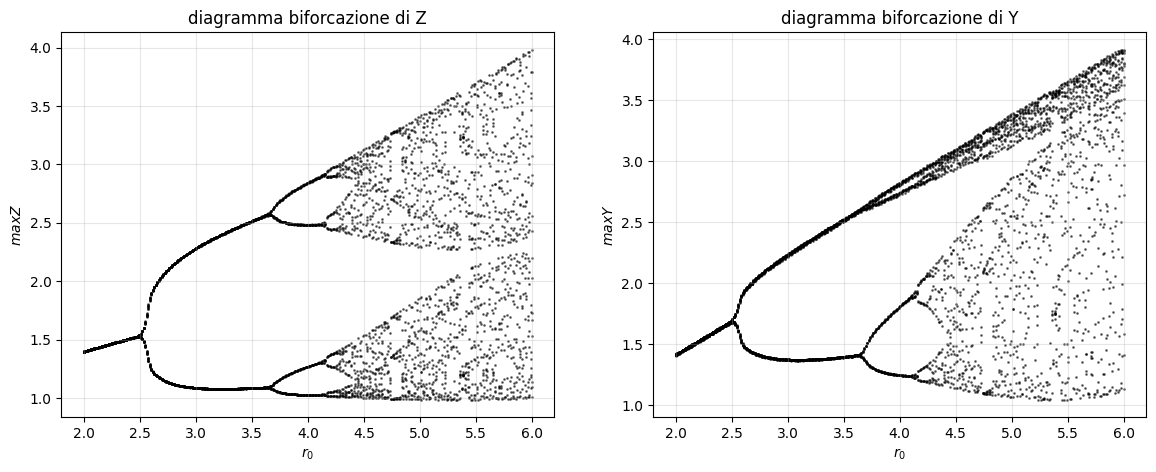

In [11]:
plotresults(r_ploty, r_plotz, y_plot, z_plot)

# 6 < r0 < 9

In [12]:
r_plotz = []
r_ploty = []
z_plot = []
y_plot = []

print("Simulazione in corso...")

# variazione di r_values
r_values = np.linspace(6,9,300)

for r in r_values:
    # Condizioni iniziali fisse come da paper
    y_init = [0.1, 0.1, 0.1]
    
    # Usiamo RK45
    sol = solve_ivp(
        beddingtonAngelis, t_span, y_init, args=(r,k0, ), 
        t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-8)
    
    z_values = sol.y[2]
    y_values = sol.y[1]
    # find_peaks trova i massimi locali per il diagramma
    peaksz, _ = find_peaks(z_values)

    # aggiungiamo distanza
    peaksy, _ = find_peaks(y_values, prominence=5e-3)
        
    if len(peaksz) > 0 and len(peaksy) > 0:
        # Prendiamo i picchi unici per evitare sovrapposizioni inutili
        for p in peaksz[-30:]: 
            r_plotz.append(r)
            z_plot.append(z_values[p])
        for p in peaksy[-30:]:
            r_ploty.append(r)
            y_plot.append(y_values[p])
            

Simulazione in corso...


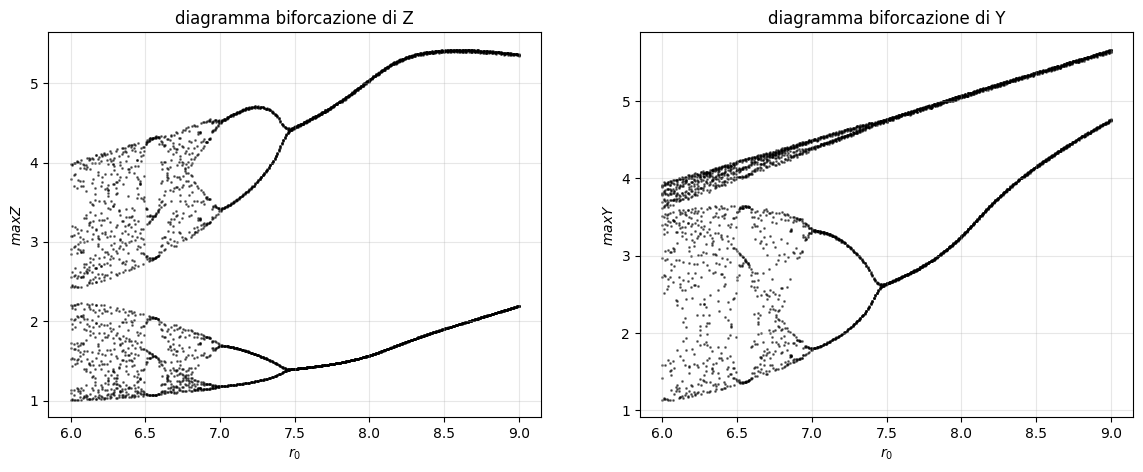

In [13]:
plotresults(r_ploty, r_plotz, y_plot, z_plot)

### VISUALIZZAZIONE DEGLI ATTRATTORI

In [14]:
x_plot = []
y_plot = []
z_plot = []

# condizioni iniziali della simulazione
X0 = 0.1
Y0 = 0.1
Z0 = 0.1

y0 = [X0, Y0, Z0]

# simuliamo per 2000 unità di tempo, analizzando le ultime 400

t_span = (0,2000)
t_eval = np.linspace(1600, 2000, 2000)


In [24]:
parametri = [2.1, 3, 3.9, 4.2, 4.5]
y_init = [X0, Y0, Z0]

for parametro in parametri:
    
    sol = solve_ivp(
    beddingtonAngelis, t_span, y_init, args=(parametro, k0), 
    t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-8)

    # estraiamo le soluzioni dal sistema
    x_values = sol.y[0]
    y_values = sol.y[1]
    z_values = sol.y[2]
    
    #plottiamo il tutto
    fig = go.Figure(data=[go.Scatter3d(x=x_values, y=y_values, z=z_values, mode='lines')])
    
    fig.update_layout(title=f"Sistema di Beddington-Angelis parametro r0 = {parametro}",
               template = "plotly_white")

    fig.show()

In [16]:
parametri = [4.7, 4.75]
y_init = [X0, Y0, Z0]

t_span = (0,2000)
t_eval = np.linspace(1600, 2000, 2000)

for parametro in parametri:
    
    sol = solve_ivp(
    beddingtonAngelis, t_span, y_init, args=(parametro, k0), 
    t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-8)

    # estraiamo le soluzioni dal sistema
    x_values = sol.y[0]
    y_values = sol.y[1]
    z_values = sol.y[2]
    
    #plottiamo il tutto
    fig = go.Figure(data=[go.Scatter3d(x=x_values, y=y_values, z=z_values, mode='lines')])
    
    fig.update_layout(title=f"Sistema di Beddington-Angelis parametro r0 = {parametro}",
               template = "plotly_white")
    
    fig.show(renderer="browser")

### DAL CHAOS ALLA NORMALITA


In [17]:
parametri = [6.7, 7, 7.4, 8]
y_init = [X0, Y0, Z0]

t_span = (0,2000)
t_eval = np.linspace(1600, 2000, 2000)

for parametro in parametri:
    
    sol = solve_ivp(
    beddingtonAngelis, t_span, y_init, args=(parametro, k0), 
    t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-8)

    # estraiamo le soluzioni dal sistema
    x_values = sol.y[0]
    y_values = sol.y[1]
    z_values = sol.y[2]
    
    #plottiamo il tutto
    fig = go.Figure(data=[go.Scatter3d(x=x_values, y=y_values, z=z_values, mode='lines')])
    
    fig.update_layout(title=f"Sistema di Beddington-Angelis parametro r0 = {parametro}",
               template = "plotly_white")
    
    fig.show(renderer="browser")

### ULTERIORI SIMULAZIONI CON VARIAZIONE DI PARAMETRI

In [18]:
# carrying capacity di X
k1 = 4


In [19]:
k0_plotz = []
k0_ploty = []
z_plot = []
y_plot = []

print("Simulazione in corso...")
K0_values = np.linspace(1.7,4,300)

for k0 in K0_values[:-1]:
    # Condizioni iniziali fisse come da paper
    y_init = [0.1, 0.1, 0.1]
    
    # Usiamo RK45
    sol = solve_ivp(
        beddingtonAngelis, t_span, y_init, args=(5, k0,), 
        t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-8)
    
    z_values = sol.y[2]
    y_values = sol.y[1]
    # find_peaks trova i massimi locali per il diagramma
    peaksz, _ = find_peaks(z_values)

    # aggiungiamo distanza
    peaksy, _ = find_peaks(y_values, prominence=5e-3)
        
    if len(peaksz) > 0 and len(peaksy) > 0:
        # Prendiamo i picchi unici per evitare sovrapposizioni inutili
        for p in peaksz[-30:]: 
            k0_plotz.append(k0)
            z_plot.append(z_values[p])
        for p in peaksy[-30:]:
            k0_ploty.append(k0)
            y_plot.append(y_values[p])
            

Simulazione in corso...


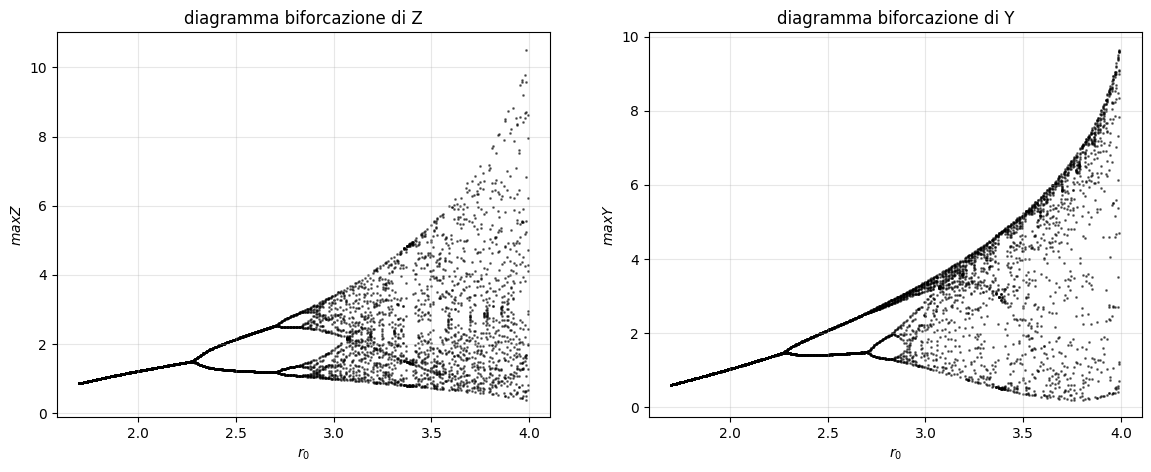

In [20]:
plotresults(k0_ploty, k0_plotz, y_plot, z_plot)

CALCOLO DEGLI ESPONENTI DI LYAPUNOV

In [21]:
import numpy as np
from symengine import symbols

# Definiamo le equazioni del sistema
# y(0)=x, y(1)=y, y(2)=z

k0_plot = []
r0_plot = []
r0lyap = []
k0lyap = []

k0_sym, r0_sym = symbols("k0 r0")


def geteuqations(k0, r0):
    f = [
        r0 * (k0 - y(0)) * y(0) / (k1 - y(0)) - (a1 * y(0) * y(1)) / (a2 * y(1) + a3 * y(0) + 1),
        (a4 * y(0) * y(1)) / (a2 * y(1) + a3 * y(0) + 1)
        - (a5 * y(1) * y(2)) / (a6 * y(2) + a7 * y(1) + a8)
        - y(1),
        (a9 * y(1) * y(2)) / (a6 * y(2) + a7 * y(1) + a8) - a10 * y(2),
    ]
    return f


r0_values = np.linspace(2, 7.04, 100)
k0_values = np.linspace(1.7, 3.30, 100)

# Compila una sola volta e varia i parametri con set_parameters
f_sym = geteuqations(k0_sym, r0_sym)
ODE_r0 = jitcode_lyap(f_sym, n_lyap=3, control_pars=[k0_sym, r0_sym])
ODE_r0.generate_f_lambda()
ODE_r0.set_integrator("dopri5")

# IMPLEMENTAZIONE PER r0
for r0 in r0_values:
    ODE_r0.set_parameters(3.0, float(r0))
    ODE_r0.set_initial_value([0.1, 0.1, 0.1], 0.0)

    # Transiente
    ODE_r0.integrate(1000.0)

    # out = (stato, esponenti_lyapunov, vettori_tangenti)
    #out = ODE_r0.integrate(2000.0)

    # Massimo esponente di Lyapunov
    
    local_lle = []
    t_now = 1000.0
    for _ in range(12):
        t_now += 100.0
        out = ODE_r0.integrate(t_now)
        local_lle.append(float(out[1][0]))

    r0lyap.append(np.mean(local_lle[6:]))   # media ultima metà
    

c:\Users\pinat\AppData\Local\Programs\Python\Python313\Lib\site-packages\jitcode\_jitcode.py:771: RuntimeWarning:

divide by zero encountered in log



In [22]:
# IMPLEMENTAZIONE PER K0

f_sym = geteuqations(k0_sym, r0_sym)
ODE_k0 = jitcode_lyap(f_sym, n_lyap=3, control_pars=[k0_sym, r0_sym])
ODE_k0.generate_f_lambda()
ODE_k0.set_integrator("dopri5")

for k0 in k0_values:
    ODE_k0.set_parameters(float(k0), 5.0)
    ODE_k0.set_initial_value([0.1, 0.1, 0.1], 0.0)

    # Transiente
    ODE_k0.integrate(1000.0)

    # out = (stato, esponenti_lyapunov, vettori_tangenti)
    
    local_lle = []
    t_now = 1000.0
    for _ in range(12):
        t_now += 100.0
        out = ODE_k0.integrate(t_now)
        local_lle.append(float(out[1][0]))

    k0lyap.append(np.mean(local_lle[6:]))   # media ultima metà

### PLOTTING DEI RISULTATI

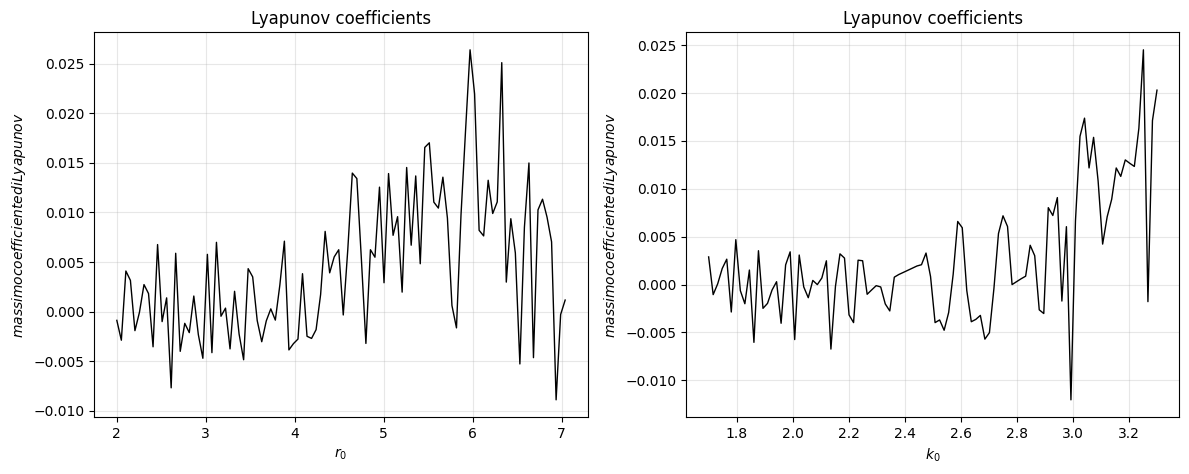

In [23]:

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (14,5))

ax1.plot(r0_values, r0lyap, 'k-', lw=1, label="Massimo esponente di lyapunov")
ax1.set_title("Lyapunov coefficients")
ax1.set_xlabel('$r_0$')
ax1.set_ylabel('$massimo coefficiente di Lyapunov$')
ax1.grid(alpha=0.3)

# Grafico biforcazione di Y
ax2.plot(k0_values, k0lyap, 'k-', lw = 1, label = "Massimo esponente di Lyapunov")
ax2.set_title("Lyapunov coefficients")
ax2.set_xlabel('$k_0$')
ax2.set_ylabel('$massimo coefficiente di Lyapunov$')
ax2.grid(alpha=0.3)